Saving outputs to: /Users/sanjanawadhawan/Downloads/outputs
              Datetime  Consumption_MW  Forecast_DayMinus1_MW  \
0  2018-01-08 00:00:00         62642.0                60500.0   
1  2018-01-08 00:30:00         61117.0                58800.0   
2  2018-01-08 01:00:00         58619.0                56700.0   
3  2018-01-08 01:30:00         58177.0                57400.0   
4  2018-01-08 02:00:00         57722.0                56900.0   

   Forecast_Day_MW  Hour  Minute  DayOfWeek  Month  DayOfYear  IsWeekend  ...  \
0          61200.0     0       0          0      1          8          0  ...   
1          59400.0     0      30          0      1          8          0  ...   
2          57200.0     1       0          0      1          8          0  ...   
3          57800.0     1      30          0      1          8          0  ...   
4          57500.0     2       0          0      1          8          0  ...   

   Lag_336   Temp_CC   Temp_CE   Temp_CW   Temp_NC   Temp_NE  

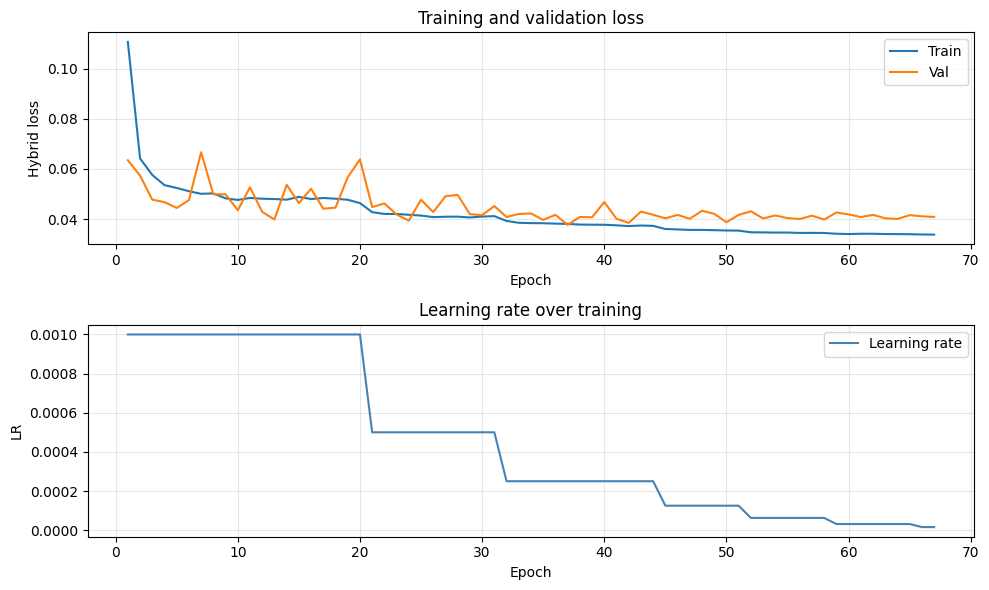

Saved: /Users/sanjanawadhawan/Downloads/outputs/nbeats_training_final.png

Results (Val):
  MAE                     : 1,122.63 MW
  RMSE                    : 1,622.59 MW
  MAPE                    : 2.17%
  sMAPE                   : 2.16%
  95% CI coverage         : 91.9%  (target is ~95%)
  Percentage in tolerance : 98.5%  (within ±10%)

Results (Test (sparse)):
  MAE                     : 1,214.74 MW
  RMSE                    : 1,732.65 MW
  MAPE                    : 2.41%
  sMAPE                   : 2.40%
  95% CI coverage         : 89.7%  (target is ~95%)
  Percentage in tolerance : 98.3%  (within ±10%)

Results (Test (dense)):
  MAE                     : 1,274.48 MW
  RMSE                    : 1,762.23 MW
  MAPE                    : 2.56%
  sMAPE                   : 2.55%
  95% CI coverage         : 88.7%  (target is ~95%)
  Percentage in tolerance : 98.5%  (within ±10%)


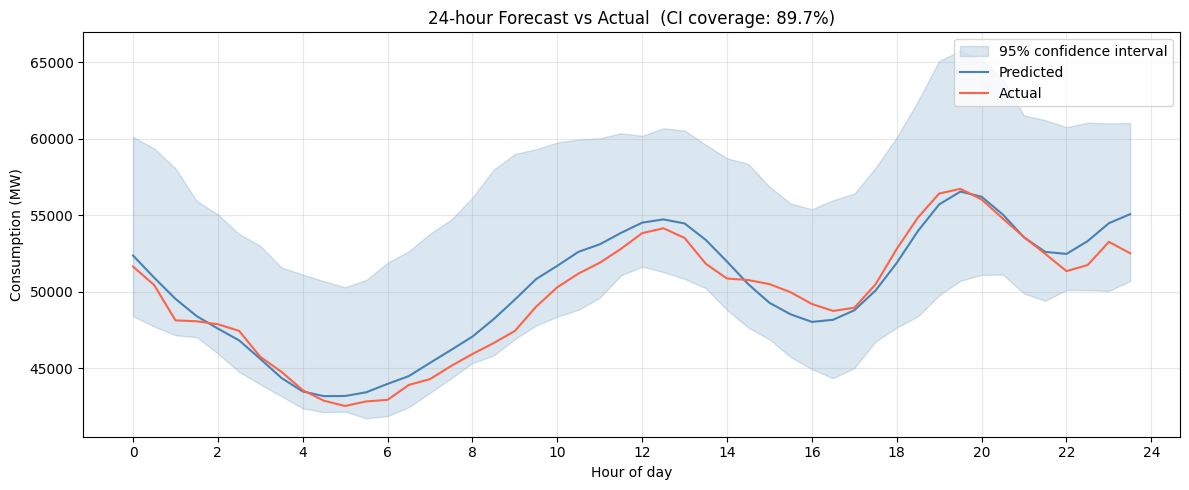

Saved: /Users/sanjanawadhawan/Downloads/outputs/predictions_with_ci_final.png


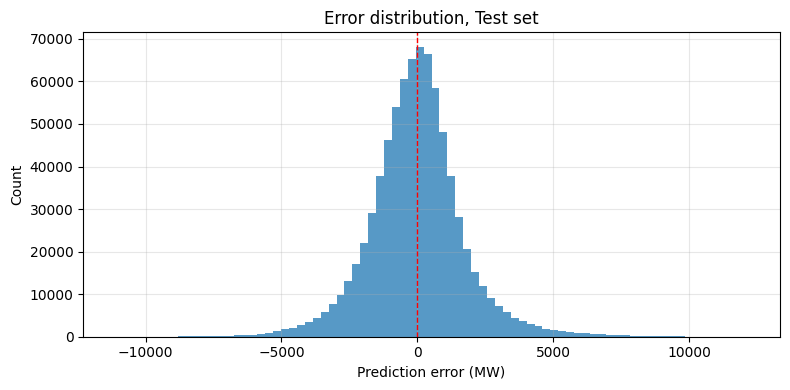

Saved: /Users/sanjanawadhawan/Downloads/outputs/error_dist_test_final.png


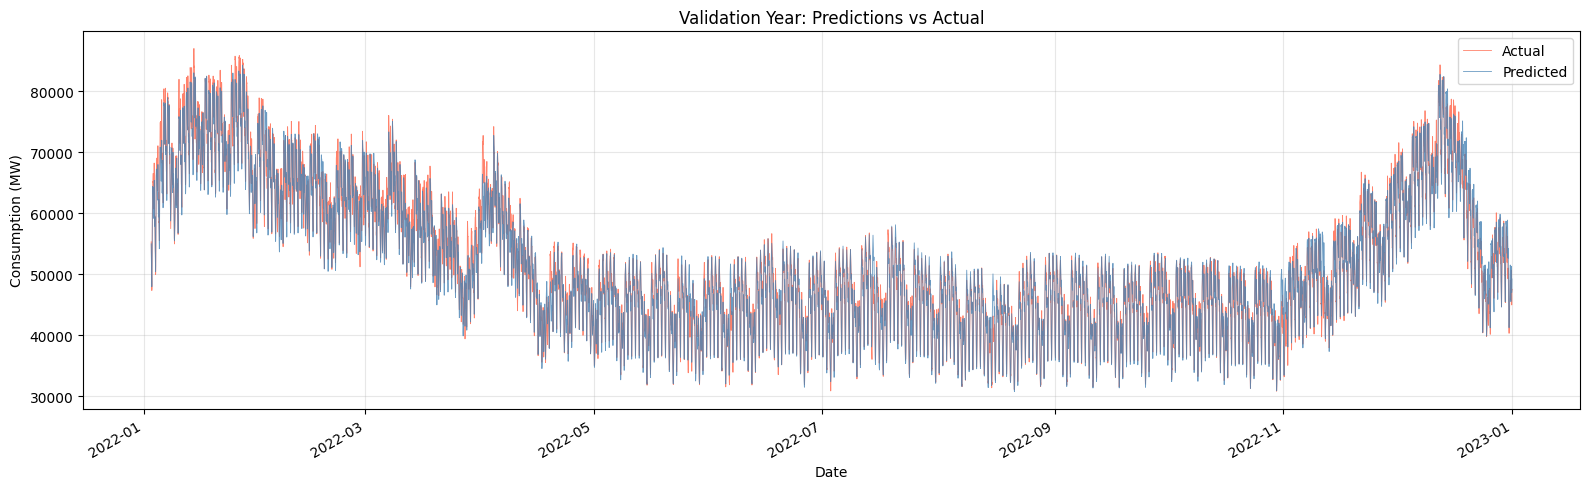

Saved: /Users/sanjanawadhawan/Downloads/outputs/Validation_Year_Predictions_vs_Actual.png


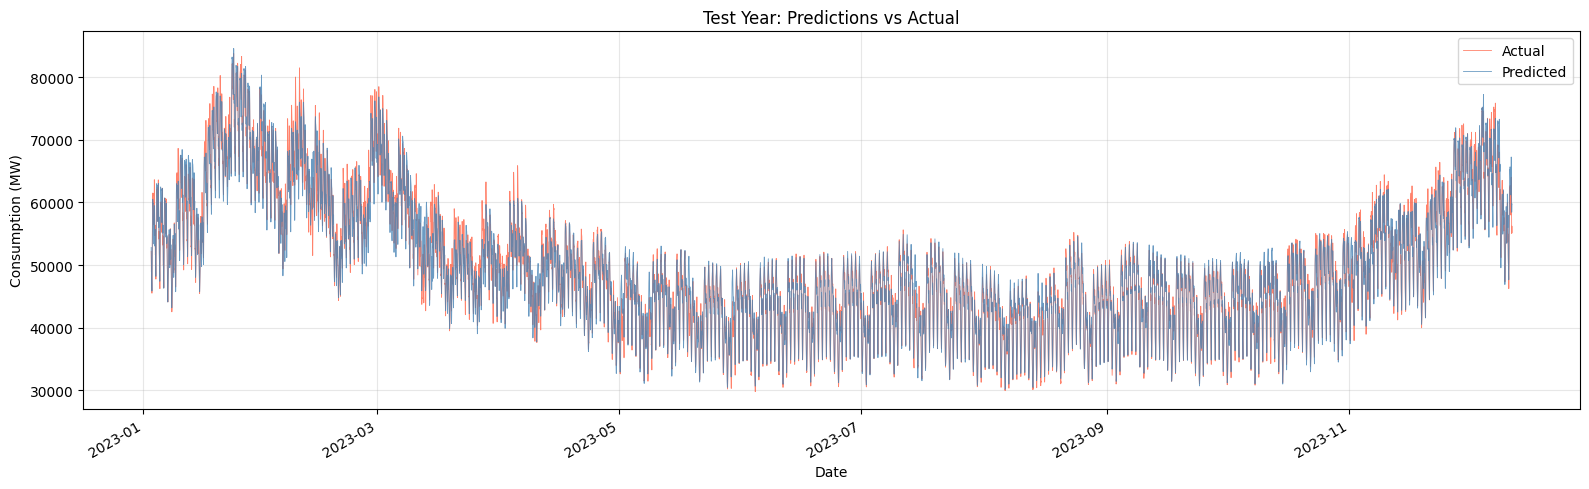

Saved: /Users/sanjanawadhawan/Downloads/outputs/Test_Year_Predictions_vs_Actual.png


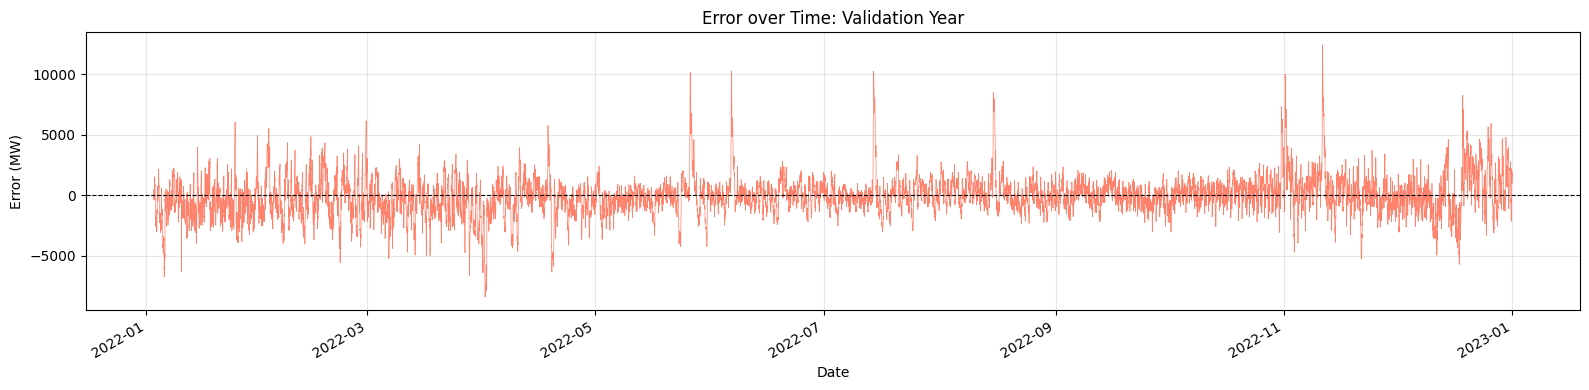

Saved: /Users/sanjanawadhawan/Downloads/outputs/Error_over_Time_Validation_Year.png


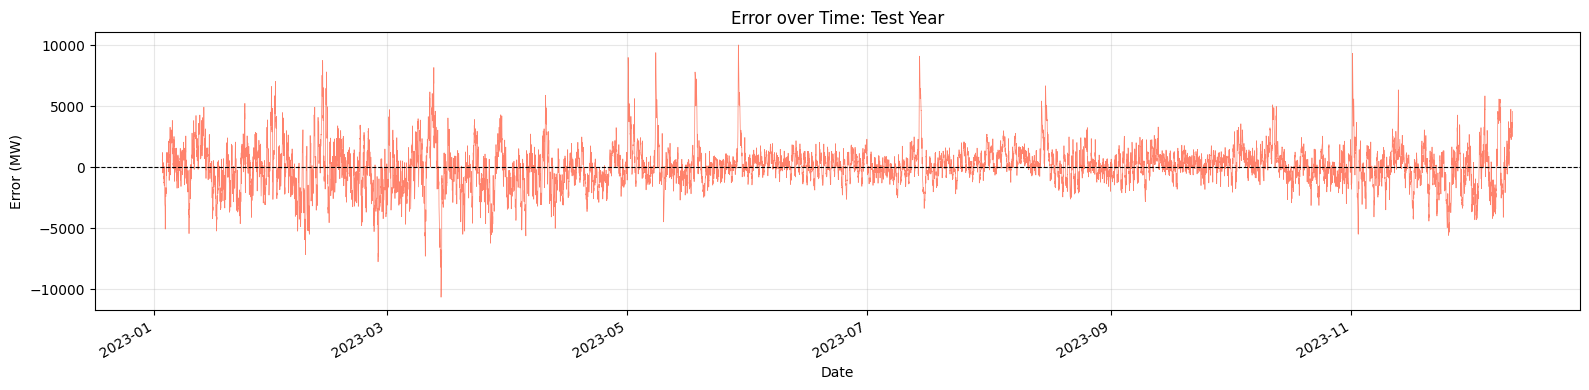

Saved: /Users/sanjanawadhawan/Downloads/outputs/Error_over_Time_Test_Year.png
Model saved to /Users/sanjanawadhawan/Downloads/outputs/nbeats_energy_final.pt

Summary table:
        Split    MAE (MW)  MAPE (%)  Confidence interval (%)  Percentage in Tolerance (%)
   Validation 1122.626572  2.173917                91.884757                    98.542241
Test (sparse) 1214.743264  2.414308                89.735180                    98.299320
 Test (dense) 1274.484849  2.561237                88.672919                    98.469902


In [2]:
import os
import warnings
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


FILEPATH = "/Users/sanjanawadhawan/Downloads/Merged_Energy_Weather_30min_Final.csv"

def get_writable_output_dir(filepath):
    candidates = [
        Path(filepath).expanduser().resolve().parent / "outputs",
        Path.home() / "Downloads" / "outputs",
        Path.cwd() / "outputs",
        Path(tempfile.gettempdir()) / "nbeats_outputs",
    ]

    for path in candidates:
        try:
            path.mkdir(parents=True, exist_ok=True)
            test_file = path / ".write_test"
            with open(test_file, "w") as f:
                f.write("ok")
            test_file.unlink()
            return path
        except Exception:
            continue

    raise OSError("Could not find any writable output directory.")

OUTPUT_DIR = get_writable_output_dir(FILEPATH)
print(f"Saving outputs to: {OUTPUT_DIR}")

df = pd.read_csv(FILEPATH)
print(df.head())

DATETIME_COL = "Datetime"
TARGET_COL   = "Consumption_MW"

TEMP_COLS = [
    "Temp_CC", "Temp_CE", "Temp_CW",
    "Temp_NC", "Temp_NE", "Temp_NW",
    "Temp_SC", "Temp_SE", "Temp_SW",
]

FORECAST_COLS = ["Forecast_DayMinus1_MW", "Forecast_Day_MW"]

#We encode hour, day-of-week, and month as sin/cos pairs rather than
# raw integers. The problem with raw integers is that e.g. hour 23 and
# hour 0 look like opposites to the model when they're actually adjacent.
# Sin/cos wraps the cycle so the distance between 23 and 0 is the same
# as between any other neighbouring hours.
CALENDAR_COLS = [
    "Hour_sin", "Hour_cos",
    "DOW_sin",  "DOW_cos",
    "Month_sin", "Month_cos",
    "IsWeekend",
]

# Lag_48 = same time yesterday, Lag_336 = same time last week.
# These are usually the strongest predictors for energy data because
# consumption patterns repeat daily and weekly.
LAG_COLS = ["Lag_48", "Lag_336"]

# Target goes first so TARGET_INDEX = 0 always points to it.
FEATURE_COLS = [TARGET_COL] + FORECAST_COLS + CALENDAR_COLS + LAG_COLS + TEMP_COLS
TARGET_INDEX = 0

# 48 steps = 24 hours at 30-min resolution (one full day ahead).
# 96 steps lookback = 2 days of history. We tried 336 (7 days) but
# the input vector became too large for the flat MLP and accuracy dropped.
HORIZON  = 48
LOOKBACK = 96

# 7 stacks was chosen after trying 10 — the extra stacks didn't improve
# val loss and made overfitting slightly worse.
N_STACKS = 7
N_BLOCKS = 1
N_HIDDEN = 256
N_LAYERS = 4
N_THETA  = None #defaults to HORIZON inside the block

BATCH_SIZE = 256
N_EPOCHS   = 150
LR         = 1e-3
PATIENCE   = 30 #has been increased from 10 as per prof's feedback during meeting
MC_SAMPLES = 200
TOLERANCE_PCT = 10   # percentage error threshold for "Percentage in Tolerance (%)"


INFERENCE_DROPOUT = 0.5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Feature engineering
def add_cyclical_features(df: pd.DataFrame) -> pd.DataFrame:
    #Subtract 1 from Month so it runs 0-11 before scaling,
    # otherwise January and December end up far apart.
    df = df.copy()
    df["Hour_sin"]  = np.sin(2 * np.pi * df["Hour"] / 24)
    df["Hour_cos"]  = np.cos(2 * np.pi * df["Hour"] / 24)
    df["DOW_sin"]   = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["DOW_cos"]   = np.cos(2 * np.pi * df["DayOfWeek"] / 7)
    df["Month_sin"] = np.sin(2 * np.pi * (df["Month"] - 1) / 12)
    df["Month_cos"] = np.cos(2 * np.pi * (df["Month"] - 1) / 12)
    return df

# Data loading and splitting
def load_and_split(filepath: str):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File not found: {filepath}")

    df = pd.read_csv(filepath)
    print("\nColumns in file:")
    print(df.columns.tolist())

    df[DATETIME_COL] = pd.to_datetime(df[DATETIME_COL], errors="coerce")
    df = df.sort_values(DATETIME_COL)
    df = add_cyclical_features(df)

    required = [DATETIME_COL] + FEATURE_COLS
    missing  = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}\nAvailable: {df.columns.tolist()}")

    df = df[[DATETIME_COL] + FEATURE_COLS].copy()
    df = df.dropna(subset=[DATETIME_COL] + FEATURE_COLS)
    df = df.set_index(DATETIME_COL)
# Temporal split
    train = df["2018":"2021"].copy()
    val   = df["2022":"2022"].copy()
    test  = df["2023":"2023"].copy()

    if len(train) == 0 or len(val) == 0 or len(test) == 0:
        raise ValueError("At least one split is empty, check the date ranges in the data.")

    print(f"\nTrain : {train.index[0]} to {train.index[-1]} ({len(train):,} rows)")
    print(f"Val   : {val.index[0]} to {val.index[-1]} ({len(val):,} rows)")
    print(f"Test  : {test.index[0]} to {test.index[-1]} ({len(test):,} rows)")

    print("\nFeatures:")
    for i, col in enumerate(FEATURE_COLS):
        tag = " <- target" if i == TARGET_INDEX else ""
        print(f"  [{i:02d}] {col}{tag}")
    print(f"\n  Total: {len(FEATURE_COLS)}")

    return train, val, test

# scaler fit only on training data to avoid leaking val/test statistics into the normalisation. Val and test are transformed using the training min/max.
def fit_scale(train_df, val_df, test_df):
    scaler   = MinMaxScaler(feature_range=(0, 1))
    train_sc = scaler.fit_transform(train_df.values)
    val_sc   = scaler.transform(val_df.values)
    test_sc  = scaler.transform(test_df.values)
    return train_sc, val_sc, test_sc, scaler


class TimeSeriesDataset(Dataset):
    # Builds sliding windows of shape (lookback, n_features) -> (horizon,)
    # stride=1 during training gives maximum sample count.
    # stride=HORIZON during val/test gives non-overlapping windows, which avoids inflating the sample count and gives a cleaner metric.
    def __init__(self, data, lookback, horizon, target_index=0, stride=1):
        self.X, self.y = [], []
        max_start = len(data) - lookback - horizon + 1
        for i in range(0, max_start, stride):
            self.X.append(data[i:i + lookback, :])
            self.y.append(data[i + lookback:i + lookback + horizon, target_index])
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class NBeatsBlock(nn.Module):
    # Each block flattens its input window, runs it through a shared FC stack, then projects to two output spaces: a backcast (what this block explains
    # about the past) and a forecast (its contribution to the future). Dropout is placed after every ReLU to regularise the flat MLP.
    def __init__(self, lookback, horizon, n_features,
                 n_hidden=256, n_layers=4, n_theta=None, dropout=0.2):
        super().__init__()

        if n_theta is None:
            n_theta = horizon

        self.lookback   = lookback
        self.horizon    = horizon
        self.n_features = n_features

        in_features = lookback * n_features

        layers = []
        for _ in range(n_layers):
            layers += [nn.Linear(in_features, n_hidden), nn.ReLU(), nn.Dropout(p=dropout)]
            in_features = n_hidden

        self.fc_stack = nn.Sequential(*layers)
        # theta is an intermediate bottleneck that the basis functions project from.
        # bias=False keeps the output scale clean. 
        self.theta_b = nn.Linear(n_hidden, n_theta, bias=False)
        self.theta_f = nn.Linear(n_hidden, n_theta, bias=False)
        self.basis_b = nn.Linear(n_theta, lookback, bias=False)
        self.basis_f = nn.Linear(n_theta, horizon, bias=False)

    def forward(self, x):
        h               = self.fc_stack(x.reshape(x.size(0), -1))
        backcast_target = self.basis_b(self.theta_b(h))
        forecast        = self.basis_f(self.theta_f(h))
        return backcast_target, forecast


class NBeatsStack(nn.Module):
    # A stack chains multiple blocks together using the residual connection: each block receives the part of the signal the previous blocks couldn't explain, so the architecture decomposes the signal progressively rather than all at once.
    def __init__(self, n_blocks, lookback, horizon, n_features,
                 n_hidden, n_layers, n_theta, dropout=0.2):
        super().__init__()
        self.blocks = nn.ModuleList([
            NBeatsBlock(lookback, horizon, n_features,
                        n_hidden, n_layers, n_theta, dropout)
            for _ in range(n_blocks)
        ])
        self.horizon = horizon

    def forward(self, x):
        residual_x     = x
        stack_forecast = torch.zeros(x.size(0), self.horizon, device=x.device)

        for block in self.blocks:
            backcast_target, forecast = block(residual_x)
            new_target = residual_x[:, :, 0] - backcast_target
            residual_x = torch.cat([new_target.unsqueeze(-1), residual_x[:, :, 1:]], dim=2)
            stack_forecast = stack_forecast + forecast

        return residual_x, stack_forecast


class NBeats(nn.Module):
     #The full model stacks multiple NBeatsStacks and sums their forecasts.
    def __init__(self, n_stacks=7, n_blocks=1, lookback=96, horizon=48,
                 n_features=20, n_hidden=256, n_layers=4, n_theta=None, dropout=0.2):
        super().__init__()
        self.stacks = nn.ModuleList([
            NBeatsStack(n_blocks, lookback, horizon, n_features,
                        n_hidden, n_layers, n_theta, dropout)
            for _ in range(n_stacks)
        ])
        self.horizon = horizon

    def forward(self, x):
        residual_x     = x
        total_forecast = torch.zeros(x.size(0), self.horizon, device=x.device)
        for stack in self.stacks:
            residual_x, forecast = stack(residual_x)
            total_forecast = total_forecast + forecast
        return total_forecast

# Loss functions
def smape_loss(forecast, target):
    eps   = 1e-8
    denom = torch.abs(forecast) + torch.abs(target) + eps
    return torch.mean(2.0 * torch.abs(forecast - target) / denom)


def hybrid_loss(forecast, target, alpha=0.5):
    s = smape_loss(forecast, target)
    m = torch.mean(torch.abs(forecast - target))
    return alpha * s + (1.0 - alpha) * m

# Training loop
def train_model(model, train_loader, val_loader,
                n_epochs=100, lr=1e-3, patience=20, device="cpu"):
     # complementary regularisation.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    # ReduceLROnPlateau halves the LR whenever val loss hasn't improved for 4 epochs. This is more adaptive than a fixed cosine schedule, which would keep decaying even if the model hasn't converged yet
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=6, min_lr=1e-6
    )

    best_val_loss     = float("inf")
    best_state        = None
    epochs_no_improve = 0
    history           = []

    model.to(device)

    for epoch in range(1, n_epochs + 1):
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = hybrid_loss(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                val_losses.append(
                    hybrid_loss(model(X_batch.to(device)), y_batch.to(device)).item()
                )

        train_loss = float(np.mean(train_losses))
        val_loss   = float(np.mean(val_losses))
        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "lr": current_lr,
        })

        print(f"Epoch {epoch:03d}  train: {train_loss:.4f}  val: {val_loss:.4f}  lr: {current_lr:.2e}")

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            best_state        = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best val: {best_val_loss:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored weights from best epoch (val loss: {best_val_loss:.4f})")

    return history, model


def enable_dropout(model, p=None):
    # Switches Dropout layers to train mode so they stay stochastic during MC inference. If p is given, we also override the dropout rate for these passes. This lets us use a higher rate at inference
    # time than during training, which is how we get a wide enough CI band to achieve close to 95% coverage without hurting training stability.
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()
            if p is not None:
                m.p = p


def mc_predict(model, X_tensor, n_samples=100, device="cpu"):
    model.eval()
    # Use INFERENCE_DROPOUT (0.5) here instead of the training rate (0.2).
    # More aggressive dropout during MC passes spreads the sample distribution wider, pushing CI coverage up toward 95%.
    enable_dropout(model, p=INFERENCE_DROPOUT)

    samples  = []
    X_tensor = X_tensor.to(device)

    with torch.no_grad():
        for _ in range(n_samples):
            samples.append(model(X_tensor).cpu().numpy())

    samples   = np.stack(samples, axis=0)
    mean_pred = samples.mean(axis=0)
    lower_95  = np.percentile(samples, 2.5, axis=0)
    upper_95  = np.percentile(samples, 97.5, axis=0)

    return mean_pred, lower_95, upper_95


def evaluate_with_ci(model, loader, scaler,
                     device="cpu", target_index=0, n_mc_samples=100, label=""):

    all_X, all_true = [], []
    for X_batch, y_batch in loader:
        all_X.append(X_batch)
        all_true.append(y_batch.numpy())

    X_all  = torch.cat(all_X, dim=0)
    trues  = np.concatenate(all_true).flatten()
    n_feat = len(scaler.scale_)

    model.eval()
    with torch.no_grad():
        preds = model(X_all.to(device)).cpu().numpy()

    _, lower_mc, upper_mc = mc_predict(model, X_all, n_samples=n_mc_samples, device=device)

    def inv(arr_1d):
        dummy = np.zeros((len(arr_1d), n_feat))
        dummy[:, target_index] = arr_1d
        return scaler.inverse_transform(dummy)[:, target_index]

    preds_mw = inv(preds.flatten())
    trues_mw = inv(trues)
    lower_mw = inv(lower_mc.flatten())
    upper_mw = inv(upper_mc.flatten())

    mae   = mean_absolute_error(trues_mw, preds_mw)
    rmse  = np.sqrt(mean_squared_error(trues_mw, preds_mw))
    mape  = np.mean(np.abs((trues_mw - preds_mw) / (trues_mw + 1e-8))) * 100
    smape = np.mean(
        2 * np.abs(trues_mw - preds_mw) /
        (np.abs(trues_mw) + np.abs(preds_mw) + 1e-8)
    ) * 100

    coverage = np.mean((trues_mw >= lower_mw) & (trues_mw <= upper_mw)) * 100

    tol_pct_values = [5, 10, 20]
    tol_results = {
        pct: float(np.mean(
            (np.abs(preds_mw - trues_mw) / (np.abs(trues_mw) + 1e-8)) * 100 <= pct
        ) * 100)
        for pct in tol_pct_values
    }
    pct_in_tolerance = tol_results[TOLERANCE_PCT]

    header = f"Results ({label})" if label else "Results"
    print(f"\n{header}:")
    print(f"  MAE                     : {mae:,.2f} MW")
    print(f"  RMSE                    : {rmse:,.2f} MW")
    print(f"  MAPE                    : {mape:.2f}%")
    print(f"  sMAPE                   : {smape:.2f}%")
    print(f"  95% CI coverage         : {coverage:.1f}%  (target is ~95%)")
    print(f"  Percentage in tolerance : {pct_in_tolerance:.1f}%  (within ±{TOLERANCE_PCT}%)")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "sMAPE": smape,
        "coverage_95": coverage,
        "pct_in_tolerance": pct_in_tolerance,
        "tol_5pct": tol_results[5],
        "tol_10pct": tol_results[10],
        "tol_20pct": tol_results[20],
        "preds_mw": preds_mw,
        "trues_mw": trues_mw,
        "lower_mw": lower_mw,
        "upper_mw": upper_mw,
    }

# Plotting
def plot_loss(history):
    epochs     = [h["epoch"] for h in history]
    train_loss = [h["train_loss"] for h in history]
    val_loss   = [h["val_loss"] for h in history]
    lrs        = [h["lr"] for h in history]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

    ax1.plot(epochs, train_loss, label="Train")
    ax1.plot(epochs, val_loss, label="Val")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Hybrid loss")
    ax1.set_title("Training and validation loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, lrs, color="steelblue", label="Learning rate")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("LR")
    ax2.set_title("Learning rate over training")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = OUTPUT_DIR / "nbeats_training_final.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {save_path}")


def plot_predictions_with_ci(results, window_idx=5, title="24-hour Forecast vs Actual"):
    start = window_idx * HORIZON
    end   = start + HORIZON

    preds = results["preds_mw"][start:end]
    trues = results["trues_mw"][start:end]
    lower = results["lower_mw"][start:end]
    upper = results["upper_mw"][start:end]

    hours = np.arange(HORIZON) * 0.5

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.fill_between(hours, lower, upper, alpha=0.2, color="steelblue",
                    label="95% confidence interval")
    ax.plot(hours, preds, color="steelblue", linewidth=1.5, label="Predicted", zorder=3)
    ax.plot(hours, trues, color="tomato", linewidth=1.5, label="Actual", zorder=4)

    coverage = results.get("coverage_95", None)
    if coverage is not None:
        title += f"  (CI coverage: {coverage:.1f}%)"

    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Consumption (MW)")
    ax.set_title(title)
    ax.set_xticks(np.arange(0, 25, 2))
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = OUTPUT_DIR / "predictions_with_ci_final.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {save_path}")


def plot_error_distribution(results, label="Test"):
    errors = results["preds_mw"] - results["trues_mw"]

    fig = plt.figure(figsize=(8, 4))
    plt.hist(errors, bins=80, edgecolor="none", alpha=0.75)
    plt.axvline(0, color="red", linestyle="--", linewidth=1)
    plt.xlabel("Prediction error (MW)")
    plt.ylabel("Count")
    plt.title(f"Error distribution, {label} set")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    safe_label = label.lower().replace(" ", "_").replace("(", "").replace(")", "")
    save_path = OUTPUT_DIR / f"error_dist_{safe_label}_final.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {save_path}")


def plot_full_year(results, title="Full Year: Predictions vs Actual", dates=None):
    preds = results["preds_mw"]
    trues = results["trues_mw"]
    x     = dates if dates is not None else np.arange(len(preds))

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(x, trues, color="tomato",    linewidth=0.6, label="Actual",    alpha=0.8)
    ax.plot(x, preds, color="steelblue", linewidth=0.6, label="Predicted", alpha=0.8)
    ax.set_xlabel("Date" if dates is not None else "Time step (30-min intervals)")
    ax.set_ylabel("Consumption (MW)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    if dates is not None:
        fig.autofmt_xdate()
    plt.tight_layout()
    save_path = OUTPUT_DIR / f"{title.replace(' ', '_').replace(':', '').replace('/', '')}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {save_path}")


def plot_error_over_time(results, title="Error over Time", dates=None):
    errors = results["preds_mw"] - results["trues_mw"]
    x      = dates if dates is not None else np.arange(len(errors))

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(x, errors, color="tomato", linewidth=0.5, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Date" if dates is not None else "Time step (30-min intervals)")
    ax.set_ylabel("Error (MW)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    if dates is not None:
        fig.autofmt_xdate()
    plt.tight_layout()
    save_path = OUTPUT_DIR / f"{title.replace(' ', '_').replace(':', '').replace('/', '')}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {save_path}")


def main():
    print(f"Device: {DEVICE}\n")
    print(f"Output directory: {OUTPUT_DIR}\n")

    train_df, val_df, test_df = load_and_split(FILEPATH)

    train_sc, val_sc, test_sc, scaler = fit_scale(train_df, val_df, test_df)
    n_features = train_sc.shape[1]
    print(f"Input features: {n_features}")

    train_dataset      = TimeSeriesDataset(train_sc, LOOKBACK, HORIZON, TARGET_INDEX, stride=1)
    val_dataset        = TimeSeriesDataset(val_sc,   LOOKBACK, HORIZON, TARGET_INDEX, stride=HORIZON)
    test_dataset       = TimeSeriesDataset(test_sc,  LOOKBACK, HORIZON, TARGET_INDEX, stride=HORIZON)
    test_dataset_dense = TimeSeriesDataset(test_sc,  LOOKBACK, HORIZON, TARGET_INDEX, stride=1)

    print(f"Train samples      : {len(train_dataset):,}")
    print(f"Val samples        : {len(val_dataset):,}")
    print(f"Test samples       : {len(test_dataset):,}  (stride={HORIZON})")
    print(f"Test dense samples : {len(test_dataset_dense):,}  (stride=1)")

    train_loader      = DataLoader(train_dataset,      batch_size=BATCH_SIZE, shuffle=True)
    val_loader        = DataLoader(val_dataset,        batch_size=BATCH_SIZE, shuffle=False)
    test_loader       = DataLoader(test_dataset,       batch_size=BATCH_SIZE, shuffle=False)
    test_loader_dense = DataLoader(test_dataset_dense, batch_size=BATCH_SIZE, shuffle=False)

    model = NBeats(
        n_stacks=N_STACKS, n_blocks=N_BLOCKS,
        lookback=LOOKBACK, horizon=HORIZON,
        n_features=n_features,
        n_hidden=N_HIDDEN, n_layers=N_LAYERS,
        n_theta=N_THETA, dropout=0.2,
    )

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {total_params:,}")

    history, model = train_model(
        model, train_loader, val_loader,
        n_epochs=N_EPOCHS, lr=LR, patience=PATIENCE, device=DEVICE,
    )
    plot_loss(history)

    val_results = evaluate_with_ci(
        model, val_loader, scaler,
        device=DEVICE, target_index=TARGET_INDEX,
        n_mc_samples=MC_SAMPLES, label="Val",
    )

    test_results = evaluate_with_ci(
        model, test_loader, scaler,
        device=DEVICE, target_index=TARGET_INDEX,
        n_mc_samples=MC_SAMPLES, label="Test (sparse)",
    )

    test_results_dense = evaluate_with_ci(
        model, test_loader_dense, scaler,
        device=DEVICE, target_index=TARGET_INDEX,
        n_mc_samples=MC_SAMPLES, label="Test (dense)",
    )

    plot_predictions_with_ci(test_results, window_idx=5)
    plot_error_distribution(test_results_dense, label="Test")

    plot_full_year(val_results, title="Validation Year: Predictions vs Actual",
               dates=val_df.index[LOOKBACK:LOOKBACK + len(val_results["preds_mw"])])

    plot_full_year(test_results, title="Test Year: Predictions vs Actual",
               dates=test_df.index[LOOKBACK:LOOKBACK + len(test_results["preds_mw"])])

    plot_error_over_time(val_results, title="Error over Time: Validation Year",
                     dates=val_df.index[LOOKBACK:LOOKBACK + len(val_results["preds_mw"])])

    plot_error_over_time(test_results, title="Error over Time: Test Year",
                     dates=test_df.index[LOOKBACK:LOOKBACK + len(test_results["preds_mw"])])

    model_path = OUTPUT_DIR / "nbeats_energy_final.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "settings": {
                "feature_cols": FEATURE_COLS,
                "target_col": TARGET_COL,
                "lookback": LOOKBACK,
                "horizon": HORIZON,
                "n_stacks": N_STACKS,
                "n_blocks": N_BLOCKS,
                "n_hidden": N_HIDDEN,
                "n_layers": N_LAYERS,
                "dropout": 0.2,
                "n_features": n_features,
                "mc_samples": MC_SAMPLES,
            },
        },
        model_path,
    )
    print(f"Model saved to {model_path}")

    summary_rows = [
        ["Validation", val_results["MAE"], val_results["MAPE"], val_results["coverage_95"], val_results["pct_in_tolerance"]],
        ["Test (sparse)", test_results["MAE"], test_results["MAPE"], test_results["coverage_95"], test_results["pct_in_tolerance"]],
        ["Test (dense)", test_results_dense["MAE"], test_results_dense["MAPE"], test_results_dense["coverage_95"], test_results_dense["pct_in_tolerance"]],
    ]
    summary_df = pd.DataFrame(
        summary_rows,
        columns=["Split", "MAE (MW)", "MAPE (%)", "Confidence interval (%)", "Percentage in Tolerance (%)"]
    )
    print("\nSummary table:")
    print(summary_df.to_string(index=False))

    return model, history, val_results, test_results, test_results_dense


if __name__ == "__main__":
    model, history, val_results, test_results, test_results_dense = main()
